ECONOCAUSAL - CAUSAL ANALYSIS
Dynamic Pricing Using Causal Machine Learning

1. CHECKING DATASET
---------------------------------------------------------------------------
Dataset found:
../data/processed/cleaned_online_retail.csv

2. LOADING DATA
---------------------------------------------------------------------------
Original Shape: (400916, 13)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour']

3. DATA TYPE CONVERSION
---------------------------------------------------------------------------
Cleaned Shape: (400916, 13)

4. TREATMENT DEFINITION
---------------------------------------------------------------------------

Treatment definition:

T = 1
Customer received a relatively lower transaction price.

T = 0
Customer received a standard/higher transaction price.

Because the Online Retail dataset does not contain
an explicit discount column, this is a price-based
tr

,count,mean,median,std
DiscountTreatment,,,,
0,221378,9.070666,3.0,61.370768
1,179538,19.558712,10.0,128.776502



Simple Average Treatment Effect: 10.488045342854571

12. PREPARING CAUSAL ML DATA
---------------------------------------------------------------------------
X Shape: (400916, 6)
T Shape: (400916,)
Y Shape: (400916,)

13. ECONML CAUSAL MACHINE LEARNING
---------------------------------------------------------------------------
EconML found successfully.
Training CausalForestDML...
Causal Forest training completed.

14. CAUSAL EFFECT RESULTS
---------------------------------------------------------------------------
Average Treatment Effect: 11.77775502627795
Median Treatment Effect: 8.70434280659459
Minimum Treatment Effect: -29.224317515347927
Maximum Treatment Effect: 3918.230462295774

15. CUSTOMER RESPONSE CLASSIFICATION
---------------------------------------------------------------------------
CustomerResponse
Positive Response    300654
High Response        100229
Negative Response        33
Name: count, dtype: int64

16. CUSTOMER LEVEL CAUSAL EFFECT
---------------------------

,CustomerID,TotalSpend,PreviousTransactions,AverageTreatmentEffect,AveragePriceReduction,CustomerResponse,RecommendedDiscount,PricingStrategy,CurrentAveragePrice,RecommendedPrice,TotalQuantity,ExpectedRevenue
1091,13902,33944.06,62,2335.127771,10.370370,High Response,20,High Discount Strategy,0.826984,0.661587,220600,145946.158730
933,13687,11872.20,44,1237.655677,16.239316,High Response,20,High Discount Strategy,0.151333,0.121067,87167,10553.018133
2498,15838,40024.92,41,1082.017888,14.430014,High Response,20,High Discount Strategy,1.494286,1.195429,46296,55343.561143
4061,17940,22579.35,16,956.622303,23.529412,High Response,20,High Discount Strategy,3.335294,2.668235,75825,202318.941176
4144,18052,10031.18,15,932.417881,23.404255,High Response,20,High Discount Strategy,0.656250,0.525000,17766,9327.150000
1179,14028,9338.00,8,729.554972,0.000000,High Response,20,High Discount Strategy,1.450000,1.160000,7170,8317.200000
3592,17308,3999.89,6,669.507601,20.238095,High Response,20,High Discount Strategy,0.887143,0.709714,5148,3653.609143
1121,13953,9572.45,4,608.949077,0.000000,High Response,20,High Discount Strategy,1.250000,1.000000,2500,2500.000000
2861,16308,1600.00,2,546.107914,0.000000,High Response,20,High Discount Strategy,0.320000,0.256000,8000,2048.000000
1053,13848,1760.00,5,541.793631,0.000000,High Response,20,High Discount Strategy,0.320000,0.256000,6500,1664.000000



19. PRICING SUMMARY
---------------------------------------------------------------------------


,PricingStrategy,Customers,AverageDiscount,AveragePrice,ExpectedRevenue
0,High Discount Strategy,1400,20.0,11.125615,1.166302e+07
1,Moderate Discount Strategy,2910,10.0,7.134053,5.289606e+06
2,No Discount Strategy,2,0.0,0.850000,1.224000e+02



20. CUSTOMER RESPONSE SUMMARY
---------------------------------------------------------------------------


CustomerResponse
Positive Response    2910
High Response        1400
Negative Response       2
Name: count, dtype: int64

Saved transaction-level causal results:
../data/processed/causal_effect_results.csv

Saved customer causal features:
../data/processed/customer_causal_features.csv

Saved final dynamic pricing dataset:
../data/processed/dynamic_pricing_recommendations.csv

21. VISUALIZATIONS
---------------------------------------------------------------------------


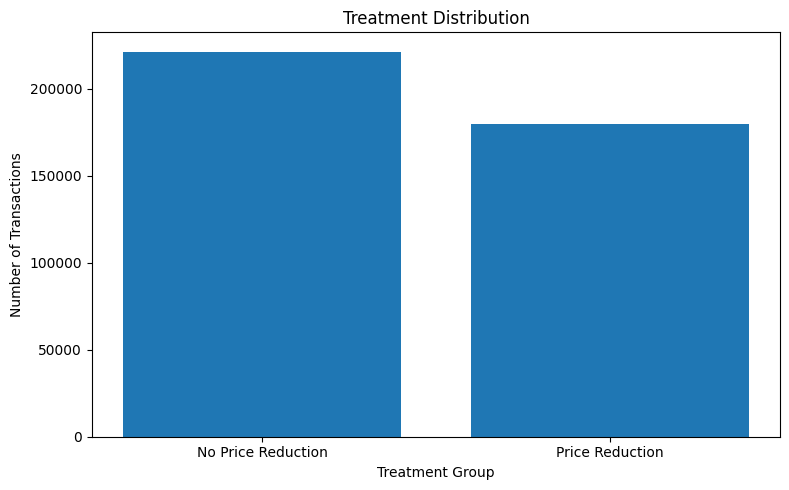

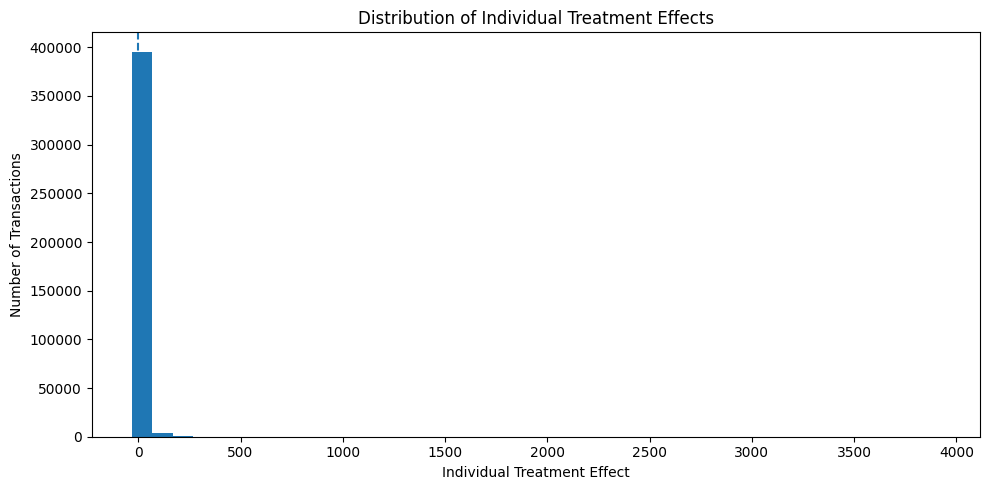

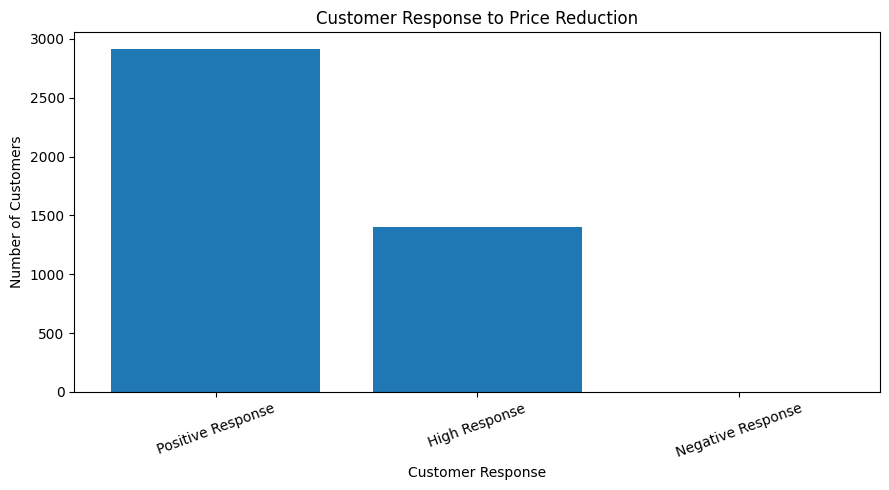

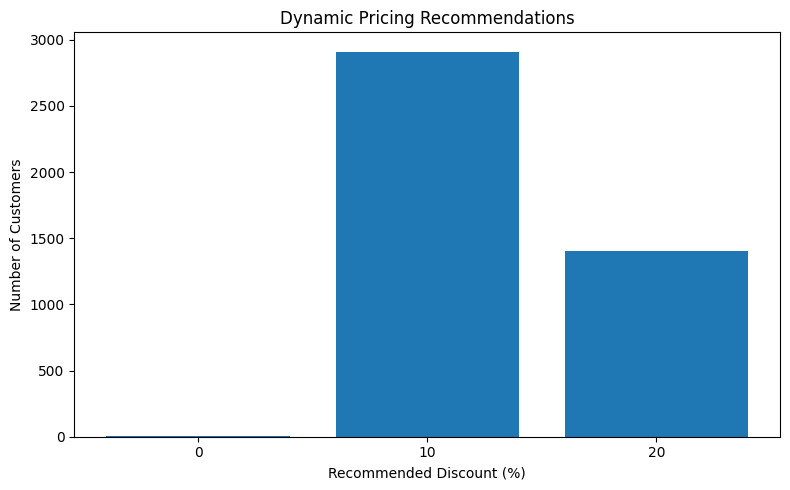



CAUSAL ANALYSIS COMPLETED SUCCESSFULLY

Total Transactions Used: 400916
Total Customers: 4312
Average Causal Treatment Effect: 11.77775502627795
Simple ATE: 10.488045342854571

Treatment:
Price Reduction Proxy

Outcome:
Purchase Quantity

Causal ML Model:
EconML CausalForestDML

Generated Files:
1. ../data/processed/causal_effect_results.csv
2. ../data/processed/customer_causal_features.csv
3. ../data/processed/dynamic_pricing_recommendations.csv

Project Flow:
Data Cleaning -> Treatment Definition -> Outcome Definition -> Confounder Engineering -> DoWhy/EconML Preparation -> Causal Forest -> Individual Treatment Effects -> Customer Response -> Dynamic Pricing

NEXT STAGE: FASTAPI BACKEND + FRONTEND DASHBOARD


In [ ]:
# ================================================================
# ECONOCAUSAL
# CAUSAL ANALYSIS USING CAUSAL MACHINE LEARNING
# ================================================================

import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")


# ================================================================
# 1. PROJECT INFORMATION
# ================================================================

print("=" * 75)
print("ECONOCAUSAL-CAUSAL ANALYSIS")
print("Dynamic Pricing Using Causal Machine Learning")
print("=" * 75)


# ================================================================
# 2. FILE PATHS
# ================================================================

input_path = "../data/processed/cleaned_online_retail.csv"

output_path = (
    "../data/processed/customer_causal_features.csv"
)

effect_path = (
    "../data/processed/causal_effect_results.csv"
)

pricing_path = (
    "../data/processed/dynamic_pricing_recommendations.csv"
)


# ================================================================
# 3. CHECK DATASET
# ================================================================

print("\n1. CHECKING DATASET")
print("-" * 75)

if not os.path.exists(input_path):

    raise FileNotFoundError(
        f"""
Dataset not found.

Expected:
{input_path}
"""
    )

print("Dataset found:")
print(input_path)


# ================================================================
# 4. LOAD DATA
# ================================================================

print("\n2. LOADING DATA")
print("-" * 75)

df = pd.read_csv(input_path)

print("Original Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ================================================================
# 5. CHECK REQUIRED COLUMNS
# ================================================================

required_columns = [
    "CustomerID",
    "InvoiceNo",
    "Quantity",
    "UnitPrice",
    "InvoiceDate"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ================================================================
# 6. DATA TYPE CONVERSION
# ================================================================

print("\n3. DATA TYPE CONVERSION")
print("-" * 75)

df["CustomerID"] = pd.to_numeric(
    df["CustomerID"],
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"],
    errors="coerce"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)


# ================================================================
# 7. REMOVE INVALID DATA
# ================================================================

df = df.dropna(
    subset=[
        "CustomerID",
        "InvoiceNo",
        "Quantity",
        "UnitPrice",
        "InvoiceDate"
    ]
)

df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()


# ================================================================
# 8. CREATE TOTAL PRICE
# ================================================================

if "TotalPrice" not in df.columns:

    df["TotalPrice"] = (
        df["Quantity"] *
        df["UnitPrice"]
    )


df = df.sort_values(
    [
        "CustomerID",
        "InvoiceDate"
    ]
).reset_index(drop=True)


print("Cleaned Shape:", df.shape)


# ================================================================
# 9. TREATMENT DEFINITION
# ================================================================

print("\n4. TREATMENT DEFINITION")
print("-" * 75)

print(
    """
Treatment definition:

T = 1
Customer received a relatively lower transaction price.

T = 0
Customer received a standard/higher transaction price.

Because the Online Retail dataset does not contain
an explicit discount column, this is a price-based
treatment proxy.
"""
)


# ================================================================
# 10. CUSTOMER BASELINE PRICE
# ================================================================

print("\n5. CUSTOMER BASELINE PRICE")
print("-" * 75)

customer_median_price = (
    df.groupby("CustomerID")["UnitPrice"]
    .median()
    .rename("CustomerMedianPrice")
)

df = df.merge(
    customer_median_price,
    on="CustomerID",
    how="left"
)


# ================================================================
# 11. CREATE TREATMENT
# ================================================================

df["DiscountTreatment"] = (
    df["UnitPrice"] <
    df["CustomerMedianPrice"]
).astype(int)


print("Treatment Distribution:")

print(
    df["DiscountTreatment"]
    .value_counts()
)


# ================================================================
# 12. CREATE PRICE REDUCTION
# ================================================================

df["PriceReductionPercent"] = np.where(
    df["CustomerMedianPrice"] > 0,
    (
        (
            df["CustomerMedianPrice"]
            - df["UnitPrice"]
        )
        /
        df["CustomerMedianPrice"]
    ) * 100,
    0
)

df["PriceReductionPercent"] = (
    df["PriceReductionPercent"]
    .clip(lower=0)
)


# ================================================================
# 13. CREATE OUTCOME
# ================================================================

print("\n6. OUTCOME DEFINITION")
print("-" * 75)

print(
    """
Outcome:

Purchase quantity is used as the transaction-level
purchasing behavior outcome.

Higher Quantity indicates stronger purchasing response.
"""
)

df["PurchaseOutcome"] = df["Quantity"]


# ================================================================
# 14. CREATE CUSTOMER HISTORICAL FEATURES
# ================================================================

print("\n7. CUSTOMER HISTORICAL FEATURES")
print("-" * 75)

# Shift ensures current transaction is not included
# in previous customer behavior.

df["PreviousQuantity"] = (
    df.groupby("CustomerID")["Quantity"]
    .cumsum()
    .shift(1)
)

df["PreviousSpend"] = (
    df.groupby("CustomerID")["TotalPrice"]
    .cumsum()
    .shift(1)
)

df["PreviousTransactions"] = (
    df.groupby("CustomerID")
    .cumcount()
)


# First transaction has no previous history.
df["PreviousQuantity"] = (
    df["PreviousQuantity"]
    .fillna(0)
)

df["PreviousSpend"] = (
    df["PreviousSpend"]
    .fillna(0)
)


# ================================================================
# 15. PREVIOUS AVERAGE ORDER VALUE
# ================================================================

df["PreviousAverageOrderValue"] = np.where(
    df["PreviousTransactions"] > 0,
    df["PreviousSpend"] /
    df["PreviousTransactions"],
    0
)


# ================================================================
# 16. PREVIOUS AVERAGE PRICE
# ================================================================

df["PreviousAveragePrice"] = (
    df.groupby("CustomerID")["UnitPrice"]
    .transform(
        lambda x:
        x.shift(1)
        .expanding()
        .mean()
    )
)

df["PreviousAveragePrice"] = (
    df["PreviousAveragePrice"]
    .fillna(df["CustomerMedianPrice"])
)


# ================================================================
# 17. RECENCY
# ================================================================

latest_date = df["InvoiceDate"].max()

df["RecencyDays"] = (
    latest_date -
    df["InvoiceDate"]
).dt.days


# ================================================================
# 18. CREATE CUSTOMER SEGMENT
# ================================================================

print("\n8. CUSTOMER SEGMENTATION")
print("-" * 75)

customer_spend = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
)

spend_q1 = customer_spend.quantile(0.33)
spend_q2 = customer_spend.quantile(0.66)


def spend_segment(value):

    if value <= spend_q1:
        return "Low"

    elif value <= spend_q2:
        return "Medium"

    else:
        return "High"


df["SpendSegment"] = (
    df["CustomerID"]
    .map(customer_spend)
    .apply(spend_segment)
)


print(
    df["SpendSegment"]
    .value_counts()
)


# ================================================================
# 19. SELECT CAUSAL FEATURES
# ================================================================

print("\n9. CAUSAL FEATURES")
print("-" * 75)

confounders = [
    "PreviousSpend",
    "PreviousTransactions",
    "PreviousQuantity",
    "PreviousAverageOrderValue",
    "PreviousAveragePrice",
    "RecencyDays"
]

print("Confounders:")

for feature in confounders:

    print("-", feature)


# ================================================================
# 20. CREATE CAUSAL DATASET
# ================================================================

causal_df = df[
    [
        "CustomerID",
        "InvoiceNo",
        "InvoiceDate",
        "UnitPrice",
        "CustomerMedianPrice",
        "PriceReductionPercent",
        "DiscountTreatment",
        "PurchaseOutcome",
        "SpendSegment"
    ]
    + confounders
].copy()


# ================================================================
# 21. REMOVE INVALID VALUES
# ================================================================

causal_df = causal_df.replace(
    [np.inf, -np.inf],
    np.nan
)

causal_df = causal_df.dropna(
    subset=[
        "DiscountTreatment",
        "PurchaseOutcome"
    ] + confounders
)

causal_df = causal_df.reset_index(
    drop=True
)


print(
    "Causal Dataset Shape:",
    causal_df.shape
)


# ================================================================
# 22. CHECK TREATMENT VARIATION
# ================================================================

print("\n10. TREATMENT DISTRIBUTION")
print("-" * 75)

treatment_counts = (
    causal_df[
        "DiscountTreatment"
    ].value_counts()
    .sort_index()
)

print(treatment_counts)

if len(treatment_counts) < 2:

    raise ValueError(
        "Treatment contains only one class. "
        "Causal estimation cannot continue."
    )


# ================================================================
# 23. TREATMENT AND OUTCOME SUMMARY
# ================================================================

print("\n11. TREATMENT VS OUTCOME")
print("-" * 75)

treatment_summary = (
    causal_df
    .groupby("DiscountTreatment")
    ["PurchaseOutcome"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)

display(treatment_summary)


# ================================================================
# 24. SIMPLE AVERAGE TREATMENT EFFECT
# ================================================================

treated_mean = causal_df[
    causal_df["DiscountTreatment"] == 1
]["PurchaseOutcome"].mean()

control_mean = causal_df[
    causal_df["DiscountTreatment"] == 0
]["PurchaseOutcome"].mean()

simple_ate = (
    treated_mean -
    control_mean
)

print(
    "\nSimple Average Treatment Effect:",
    simple_ate
)


# ================================================================
# 25. PREPARE X, T, Y
# ================================================================

print("\n12. PREPARING CAUSAL ML DATA")
print("-" * 75)

X = causal_df[
    confounders
].copy()

T = causal_df[
    "DiscountTreatment"
].astype(int).values

Y = causal_df[
    "PurchaseOutcome"
].astype(float).values


print("X Shape:", X.shape)

print("T Shape:", T.shape)

print("Y Shape:", Y.shape)


# ================================================================
# 26. RUN ECONML
# ================================================================

print("\n13. ECONML CAUSAL MACHINE LEARNING")
print("-" * 75)

try:

    from econml.dml import CausalForestDML

    print(
        "EconML found successfully."
    )

    print(
        "Training CausalForestDML..."
    )


    # Outcome model
    model_y = RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )


    # Treatment model
    model_t = RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )


    causal_model = CausalForestDML(
        model_y=model_y,
        model_t=model_t,
        n_estimators=200,
        min_samples_leaf=10,
        max_depth=10,
        discrete_treatment=True,
        random_state=42
    )


    causal_model.fit(
        Y,
        T,
        X=X
    )


    # Individual treatment effects
    treatment_effects = (
        causal_model.effect(X)
    )


    causal_df[
        "IndividualTreatmentEffect"
    ] = treatment_effects


    print(
        "Causal Forest training completed."
    )


except ImportError:

    raise ImportError(
        """
EconML is not installed.

Run:

pip install econml

Then restart the notebook kernel
and run this program again.
"""
    )


# ================================================================
# 27. AVERAGE CAUSAL EFFECT
# ================================================================

print("\n14. CAUSAL EFFECT RESULTS")
print("-" * 75)

average_causal_effect = (
    causal_df[
        "IndividualTreatmentEffect"
    ].mean()
)

median_causal_effect = (
    causal_df[
        "IndividualTreatmentEffect"
    ].median()
)

minimum_effect = (
    causal_df[
        "IndividualTreatmentEffect"
    ].min()
)

maximum_effect = (
    causal_df[
        "IndividualTreatmentEffect"
    ].max()
)


print(
    "Average Treatment Effect:",
    average_causal_effect
)

print(
    "Median Treatment Effect:",
    median_causal_effect
)

print(
    "Minimum Treatment Effect:",
    minimum_effect
)

print(
    "Maximum Treatment Effect:",
    maximum_effect
)


# ================================================================
# 28. CUSTOMER RESPONSE CLASSIFICATION
# ================================================================

print("\n15. CUSTOMER RESPONSE CLASSIFICATION")
print("-" * 75)


# Use the distribution of treatment effects
# rather than arbitrary fixed thresholds.

effect_q25 = causal_df[
    "IndividualTreatmentEffect"
].quantile(0.25)

effect_q75 = causal_df[
    "IndividualTreatmentEffect"
].quantile(0.75)


def classify_response(effect):

    if effect >= effect_q75:

        return "High Response"

    elif effect > 0:

        return "Positive Response"

    elif effect <= effect_q25:

        return "Negative Response"

    else:

        return "Low Response"


causal_df[
    "CustomerResponse"
] = causal_df[
    "IndividualTreatmentEffect"
].apply(
    classify_response
)


print(
    causal_df[
        "CustomerResponse"
    ].value_counts()
)


# ================================================================
# 29. AGGREGATE CUSTOMER-LEVEL CAUSAL EFFECT
# ================================================================

print("\n16. CUSTOMER LEVEL CAUSAL EFFECT")
print("-" * 75)

customer_effects = (
    causal_df
    .groupby("CustomerID")
    .agg(
        TotalSpend=(
            "PreviousSpend",
            "max"
        ),

        PreviousTransactions=(
            "PreviousTransactions",
            "max"
        ),

        AverageTreatmentEffect=(
            "IndividualTreatmentEffect",
            "mean"
        ),

        AveragePriceReduction=(
            "PriceReductionPercent",
            "mean"
        )
    )
    .reset_index()
)


# ================================================================
# 30. CUSTOMER RESPONSE
# ================================================================

customer_effects[
    "CustomerResponse"
] = customer_effects[
    "AverageTreatmentEffect"
].apply(
    classify_response
)


# ================================================================
# 31. RECOMMENDED DISCOUNT
# ================================================================

print("\n17. DYNAMIC PRICING RECOMMENDATION")
print("-" * 75)


def recommended_discount(effect):

    if effect >= effect_q75:

        return 20

    elif effect > 0:

        return 10

    elif effect <= effect_q25:

        return 0

    else:

        return 5


customer_effects[
    "RecommendedDiscount"
] = customer_effects[
    "AverageTreatmentEffect"
].apply(
    recommended_discount
)


# ================================================================
# 32. PRICING STRATEGY
# ================================================================


def pricing_strategy(discount):

    if discount >= 20:

        return "High Discount Strategy"

    elif discount >= 10:

        return "Moderate Discount Strategy"

    elif discount > 0:

        return "Low Discount Strategy"

    else:

        return "No Discount Strategy"


customer_effects[
    "PricingStrategy"
] = customer_effects[
    "RecommendedDiscount"
].apply(
    pricing_strategy
)


# ================================================================
# 33. CURRENT PRICE
# ================================================================

customer_average_price = (
    df.groupby("CustomerID")
    ["UnitPrice"]
    .mean()
    .rename("CurrentAveragePrice")
)


customer_effects = customer_effects.merge(
    customer_average_price,
    on="CustomerID",
    how="left"
)


# ================================================================
# 34. RECOMMENDED PRICE
# ================================================================

customer_effects[
    "RecommendedPrice"
] = (
    customer_effects[
        "CurrentAveragePrice"
    ]
    *
    (
        1 -
        customer_effects[
            "RecommendedDiscount"
        ] / 100
    )
)


# ================================================================
# 35. EXPECTED REVENUE PROXY
# ================================================================

customer_quantity = (
    df.groupby("CustomerID")
    ["Quantity"]
    .sum()
    .rename("TotalQuantity")
)

customer_effects = customer_effects.merge(
    customer_quantity,
    on="CustomerID",
    how="left"
)


customer_effects[
    "ExpectedRevenue"
] = (
    customer_effects[
        "RecommendedPrice"
    ]
    *
    customer_effects[
        "TotalQuantity"
    ]
)


# ================================================================
# 36. DISPLAY TOP RESPONSIVE CUSTOMERS
# ================================================================

print("\n18. TOP RESPONSIVE CUSTOMERS")
print("-" * 75)

top_customers = (
    customer_effects
    .sort_values(
        "AverageTreatmentEffect",
        ascending=False
    )
    .head(20)
)


display(
    top_customers
)


# ================================================================
# 37. PRICING SUMMARY
# ================================================================

print("\n19. PRICING SUMMARY")
print("-" * 75)

pricing_summary = (
    customer_effects
    .groupby("PricingStrategy")
    .agg(
        Customers=(
            "CustomerID",
            "nunique"
        ),

        AverageDiscount=(
            "RecommendedDiscount",
            "mean"
        ),

        AveragePrice=(
            "RecommendedPrice",
            "mean"
        ),

        ExpectedRevenue=(
            "ExpectedRevenue",
            "sum"
        )
    )
    .reset_index()
)


display(
    pricing_summary
)


# ================================================================
# 38. CUSTOMER RESPONSE SUMMARY
# ================================================================

print("\n20. CUSTOMER RESPONSE SUMMARY")
print("-" * 75)

response_summary = (
    customer_effects[
        "CustomerResponse"
    ]
    .value_counts()
)

display(
    response_summary
)


# ================================================================
# 39. SAVE TRANSACTION-LEVEL CAUSAL DATA
# ================================================================

causal_df.to_csv(
    effect_path,
    index=False
)

print(
    "Saved transaction-level causal results:"
)

print(
    effect_path
)


# ================================================================
# 40. CREATE FINAL CUSTOMER CAUSAL DATASET
# ================================================================

final_customer_columns = [
    "CustomerID",
    "TotalSpend",
    "TotalQuantity",
    "PreviousTransactions",
    "AverageTreatmentEffect",
    "AveragePriceReduction",
    "CustomerResponse",
    "RecommendedDiscount",
    "PricingStrategy",
    "CurrentAveragePrice",
    "RecommendedPrice",
    "ExpectedRevenue"
]

final_customer_df = customer_effects[
    final_customer_columns
].copy()


# ================================================================
# 41. SAVE CUSTOMER CAUSAL FEATURES
# ================================================================

final_customer_df.to_csv(
    output_path,
    index=False
)

print(
    "\nSaved " customer causal features:"
)

print(
    output_path
)


# ================================================================
# 42. CREATE FINAL DYNAMIC PRICING FILE
# ================================================================

pricing_df = final_customer_df.copy()

pricing_df[
    "IndividualTreatmentEffect"
] = pricing_df[
    "AverageTreatmentEffect"
]


# Keep both names useful for backend compatibility.

pricing_df[
    "RecommendedRevenue"
] = pricing_df[
    "ExpectedRevenue"
]


# ================================================================
# 43. SAVE FINAL PRICING DATASET
# ================================================================

pricing_df.to_csv(
    pricing_path,
    index=False
)

print(
    "\nSaved final dynamic pricing dataset:"
)

print(
    pricing_path
)


# ================================================================
# 44. VISUALIZATION - TREATMENT DISTRIBUTION
# ================================================================

print("\n21. VISUALIZATIONS")
print("-" * 75)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    ["No Price Reduction", "Price Reduction"],
    [
        treatment_counts.get(0, 0),
        treatment_counts.get(1, 0)
    ]
)

plt.xlabel(
    "Treatment Group"
)

plt.ylabel(
    "Number of Transactions"
)

plt.title(
    "Treatment Distribution"
)

plt.tight_layout()

plt.show()


# ================================================================
# 45. VISUALIZATION - TREATMENT EFFECT
# ================================================================

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    causal_df[
        "IndividualTreatmentEffect"
    ],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Individual Treatment Effect"
)

plt.ylabel(
    "Number of Transactions"
)

plt.title(
    "Distribution of Individual Treatment Effects"
)

plt.tight_layout()

plt.show()


# ================================================================
# 46. VISUALIZATION - CUSTOMER RESPONSE
# ================================================================

response_counts = (
    customer_effects[
        "CustomerResponse"
    ]
    .value_counts()
)


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    response_counts.index,
    response_counts.values
)

plt.xlabel(
    "Customer Response"
)

plt.ylabel(
    "Number of Customers"
)

plt.title(
    "Customer Response to Price Reduction"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ================================================================
# 47. VISUALIZATION - RECOMMENDED DISCOUNT
# ================================================================

discount_counts = (
    customer_effects[
        "RecommendedDiscount"
    ]
    .value_counts()
    .sort_index()
)


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    discount_counts.index.astype(str),
    discount_counts.values
)

plt.xlabel(
    "Recommended Discount (%)"
)

plt.ylabel(
    "Number of Customers"
)

plt.title(
    "Dynamic Pricing Recommendations"
)

plt.tight_layout()

plt.show()


# ================================================================
# 48. FINAL RESULTS
# ================================================================

print("\n")
print("=" * 75)
print("CAUSAL ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 75)

print(
    "\nTotal Transactions Used:",
    len(causal_df)
)

print(
    "Total Customers:",
    causal_df["CustomerID"].nunique()
)

print(
    "Average Causal Treatment Effect:",
    average_causal_effect
)

print(
    "Simple ATE:",
    simple_ate
)

print(
    "\nTreatment:"
)

print(
    "Price Reduction Proxy"
)

print(
    "\nOutcome:"
)

print(
    "Purchase Quantity"
)

print(
    "\nCausal ML Model:"
)

print(
    "EconML CausalForestDML"
)

print(
    "\nGenerated Files:"
)

print(
    "1.",
    effect_path
)

print(
    "2.",
    output_path
)

print(
    "3.",
    pricing_path
)


print("\nProject Flow:")

print(
    "Data Cleaning"
    " -> Treatment Definition"
    " -> Outcome Definition"
    " -> Confounder Engineering"
    " -> DoWhy/EconML Preparation"
    " -> Causal Forest"
    " -> Individual Treatment Effects"
    " -> Customer Response"
    " -> Dynamic Pricing"
)


print("\n" + "=" * 75)
print("NEXT STAGE: FASTAPI BACKEND + FRONTEND DASHBOARD")
print("=" * 75)